# TIỀN XỬ LÝ ẢNH DẤU VÂN TAY

## Các thư viện cần thiết

In [1]:
import cv2 as cv
import numpy as np
import math
import matplotlib.pyplot as plt
import scipy.ndimage

### **Bước 1: Chuẩn hóa hình ảnh (Normalization)**
Chuẩn hóa ảnh dấu vân tay dựa trên phương pháp của Hong, Wan và Jain (1998), được sử dụng trong nhận dạng dấu vân tay. Mục tiêu của việc chuẩn hóa là làm giảm tác động của nhiễu cảm biến và thay đổi cường độ do áp lực ngón tay lên cảm biến.

Sử dụng công thức:

$
x' =
\begin{cases}
m_0 + \sqrt{\frac{v_0 (x - m)^2}{v}}, & \text{nếu } x > m \\
m_0 - \sqrt{\frac{v_0 (x - m)^2}{v}}, & \text{nếu } x \leq m
\end{cases}
$

**Ý nghĩa các tham số:**

- $ x $ là giá trị pixel đầu vào.
- $ m $ là trung bình của toàn bộ ảnh gốc.
- $ v $ là phương sai (variance) của ảnh gốc.
- $ m_0 $ là trung bình mong muốn (giá trị mới trung tâm).
- $ v_0 $ là phương sai mong muốn (mức độ phân tán mong muốn).
- Nếu $ x > m $, pixel sẽ được tăng cường sáng.
- Nếu $ x \leq m $, pixel sẽ bị giảm sáng.


In [2]:
def normalize_pixel(x, v0, v, m, m0):
    """
    Normalize pixel value using the formula from Hong et al. (1998).

    :param x: Giá trị pixel gốc.
    :param v0: Độ phương sai mong muốn của ảnh sau khi chuẩn hóa.
    :param v: Độ phương sai thực tế của ảnh gốc.
    :param m: Giá trị trung bình thực tế của ảnh gốc.
    :param m0: Giá trị trung bình mong muốn sau khi chuẩn hóa.
    :return: Giá trị pixel mới sau khi chuẩn hóa.
    """
    dev_coeff = np.sqrt((v0 * ((x - m)**2)) / v)  # Hệ số điều chỉnh theo phương sai
    return m0 + dev_coeff if x > m else m0 - dev_coeff  # Điều chỉnh giá trị pixel


Thực hiện chuẩn hóa toàn bộ ảnh theo công thức trên.

In [3]:
def normalize(im, m0, v0):
    m = np.mean(im)  # Tính trung bình ảnh gốc
    v = np.std(im) ** 2  # Tính phương sai ảnh gốc (độ lệch chuẩn bình phương)
    (y, x) = im.shape  # Lấy kích thước ảnh
    normilize_image = im.copy()  # Sao chép ảnh gốc để tránh thay đổi trực tiếp

    # Lặp qua từng pixel và chuẩn hóa
    for i in range(x):
        for j in range(y):
            normilize_image[j, i] = normalize_pixel(im[j, i], v0, v, m, m0)

    return normilize_image  # Trả về ảnh đã được chuẩn hóa


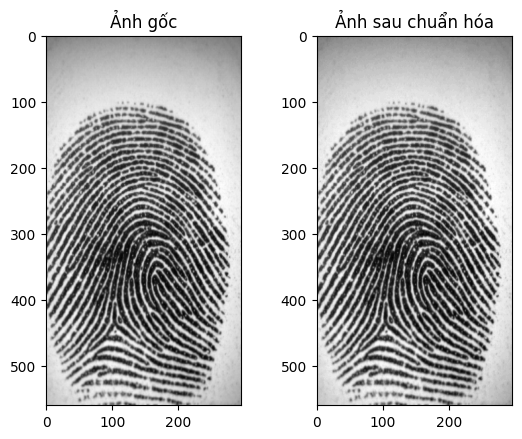

In [4]:
# Đọc ảnh vân tay mức xám
image = cv.imread("/content/fingerprint.tif", 0)

# Chuẩn hóa ảnh với giá trị trung bình 100, phương sai mong muốn 100
normalized_image = normalize(image, 100, 100)

# Hiển thị ảnh trước và sau khi chuẩn hóa
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title("Ảnh gốc")

plt.subplot(1, 2, 2)
plt.imshow(normalized_image, cmap='gray')
plt.title("Ảnh sau chuẩn hóa")

plt.show()

### **Bước 2: Phân đoạn ảnh vân tay (Fingerprint Segmentation)**

Ta thực hiện phân đoạn dấu vân tay bằng cách loại bỏ đi các vùng biên và vùng quá nhiễu -> Chỉ lấy lại các dùng có dấu vân tay. Ta dựa vào độ lệch chuẩn (standard deviation) của các khối trong ảnh. Việc này giúp tăng độ chính xác của các bước nhận dạng tiếp theo.



Ta chuẩn hóa hình ảnh bằng cách đưa giá trị cường độ pixel về trung bình 0 và độ lệch chuẩn 1.

**Công thức:**

$$
    \text{img-normalized} = \frac{\text{img} - \mu}{\sigma}
$$

- $ \mu $ = Giá trị trung bình của ảnh.
- $ \sigma $ = Độ lệch chuẩn của ảnh.

Ta có:

- Ảnh sau chuẩn hóa có trung bình 0 và phương sai 1.
- Giúp làm nổi bật các đường vân, giảm ảnh hưởng của thay đổi ánh sáng.


In [5]:
def normalise(img):
    return (img - np.mean(img)) / (np.std(img))


Tiếp theo xác định vùng quan tâm (ROI). Chia ảnh thành các khối $W \times W$ (mặc định $W = 16$), sau đó **tính phương sai (variance) của mỗi khối**.  

Phương sai của một khối được tính như sau:
$$
\sigma^2 = \frac{1}{N} \sum (x_i - \mu)^2
$$
  - Nếu **phương sai cao** → Khối chứa đường dấu vân tay.
  - Nếu **phương sai thấp** → Có thể là vùng nền hoặc vùng nhiễu.

**Tạo mask xác định vùng quan tâm (ROI)**
- Nếu phương sai **nhỏ hơn ngưỡng** (threshold = 0.2 × độ lệch chuẩn toàn ảnh) → Đặt giá trị **0** (loại bỏ khối đó khỏi vùng quan tâm).
- Nếu lớn hơn → Giữ nguyên.

Từ đó ta có thể loại bỏ vùng không quan trọng, giảm nhiễu.

**Làm mịn mask bằng phép toán hình thái học**
- **MORPH_OPEN**: Loại bỏ các điểm nhiễu nhỏ.
- **MORPH_CLOSE**: Lấp đầy các lỗ trống nhỏ trong mask.

Giúp mask trở nên rõ ràng hơn, giữ lại các đặc điểm quan trọng của dấu vân tay.

**Áp dụng mask lên ảnh và chuẩn hóa lại vùng quan tâm**
- Ảnh sau khi áp dụng mask sẽ chỉ giữ lại vùng dấu vân tay.
- Chuẩn hóa lại vùng quan tâm bằng cách tính trung bình và độ lệch chuẩn **chỉ trong ROI**.

Giữ lại chi tiết dấu vân tay rõ ràng nhất.

In [6]:
def create_segmented_and_variance_images(im, w, threshold=0.2):
    (y, x) = im.shape  # Lấy kích thước ảnh
    threshold = np.std(im) * threshold  # Ngưỡng chuẩn hóa dựa trên phương sai toàn ảnh

    # Tính  toán phương sai trên từng khối ảnh
    image_variance = np.zeros(im.shape)  # Tạo ma trận chứa giá trị phương sai của từng khối
    segmented_image = im.copy()  # Bản sao ảnh gốc để lưu kết quả phân đoạn
    mask = np.ones_like(im)  # Tạo mask với cùng kích thước ảnh gốc (ban đầu toàn bộ là 1)

    # Duyệt từng khối 16×16 trong ảnh và tính phương sai của mỗi khối
    for i in range(0, x, w):  # Lặp theo chiều ngang
        for j in range(0, y, w):  # Lặp theo chiều dọc
            box = [i, j, min(i + w, x), min(j + w, y)]
            block_stddev = np.std(im[box[1]:box[3], box[0]:box[2]])  # Tính độ lệch chuẩn của khối
            image_variance[box[1]:box[3], box[0]:box[2]] = block_stddev  # Lưu giá trị

    # Áp dụng ngưỡng để xác định vùng nền
    mask[image_variance < threshold] = 0

    # Làm mịn mask bằng phép toán hình thái học
    kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (w*2, w*2))
    mask = cv.morphologyEx(mask, cv.MORPH_OPEN, kernel)
    mask = cv.morphologyEx(mask, cv.MORPH_CLOSE, kernel)

    # Chuẩn hóa lại ảnh chỉ trong vùng quan tâm
    segmented_image *= mask  # Áp dụng mask lên ảnh (loại bỏ vùng không cần thiết)
    im = normalise(im)  # Chuẩn hóa toàn ảnh
    mean_val = np.mean(im[mask == 0])  # Tính trung bình của vùng bị loại bỏ
    std_val = np.std(im[mask == 0])  # Tính độ lệch chuẩn của vùng bị loại bỏ
    norm_img = (im - mean_val) / (std_val)  # Chuẩn hóa lại ảnh trong vùng quan tâm

    return segmented_image, norm_img, mask


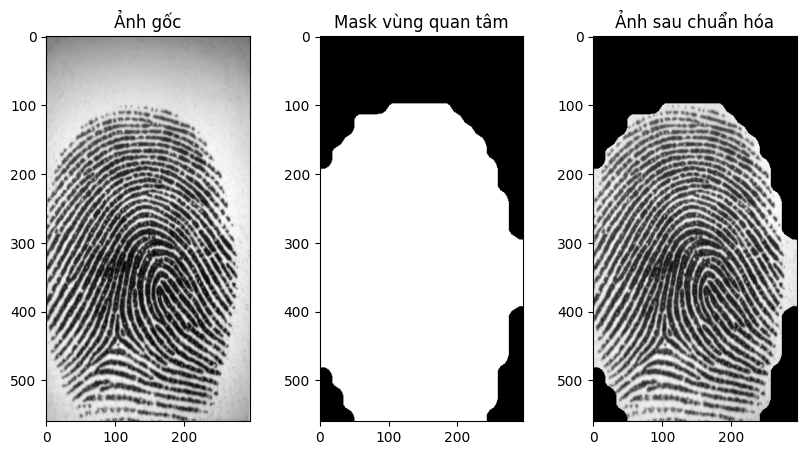

In [7]:
# Áp dụng thuật toán phân đoạn
segmented_image, norm_img, mask = create_segmented_and_variance_images(image, w=16, threshold=0.2)

# Hiển thị kết quả
plt.figure(figsize=(10,5))
plt.subplot(1,3,1)
plt.imshow(image, cmap='gray')
plt.title("Ảnh gốc")

plt.subplot(1,3,2)
plt.imshow(mask, cmap='gray')
plt.title("Mask vùng quan tâm")

plt.subplot(1,3,3)
plt.imshow(segmented_image, cmap='gray')
plt.title("Ảnh sau chuẩn hóa")

plt.show()

- Ta nhận thấy code trên tự động phát hiện vùng chứa dấu vân tay và loại bỏ phần nền.
- Chuẩn hóa ảnh giúp thuật toán nhận dạng vân tay chính xác hơn.
- Kết hợp với xử lý hình thái học, thuật toán hoạt động hiệu quả ngay cả khi ảnh bị nhiễu.

### **Bước 3: Ước lượng tính toán hướng vân tay (Fingerprint Orientation Estimation)**

**Xác định hướng của các đường vân dấu tay** trong từng khối nhỏ của ảnh. Đây là bước quan trọng trong nhận dạng dấu vân tay vì nó giúp xác định các đặc trưng như **minutiae** (giao điểm, nhánh, kết thúc của đường vân).

- **Tính gradient theo cả hai hướng x và y** bằng bộ lọc Sobel:
$$
G_x = V(x, y) *
\begin{bmatrix}
-1 & 0 & 1 \\
-2 & 0 & 2 \\
-1 & 0 & 1
\end{bmatrix}
$$

$$
G_y = V(x, y) *
\begin{bmatrix}
-1 & -2 & -1 \\
0 & 0 & 0 \\
1 & 2 & 1
\end{bmatrix}
$$

Trong đó  $V(x, y)$ là khối xung quanh điểm $(x, y)$.


- **Tính toán phương sai của gradient** trong từng khối $ W \times W $.

Đối với từng khối nhỏ, ta tính toán các đại lượng sau:

$$
V_x(i, j) = \sum_{u=i-\frac{W}{2}}^{i+\frac{W}{2}} \sum_{v=j-\frac{W}{2}}^{j+\frac{W}{2}} 2 \cdot G_x(u,v) \cdot G_y(u,v)
$$

$$
V_y(i, j) = \sum_{u=i-\frac{W}{2}}^{i+\frac{W}{2}} \sum_{v=j-\frac{W}{2}}^{j+\frac{W}{2}} \left( G_x^2(u,v) - G_y^2(u,v) \right)
$$

- **Tính góc định hướng của từng khối** bằng công thức:
   $$
   \theta(i, j) = \frac{\pi + \tan^{-1} \left(\frac{V_x(i,j)}{V_y(i,j)}\right)}{2}
   $$

**Ta cộng thêm pi/2 để đảm bảo góc tính ra luôn dương**

- **Làm mượt hướng bằng bộ lọc Gaussian** để giảm nhiễu.
- **Vẽ vector hướng lên ảnh** để trực quan hóa.



In [8]:
def calculate_angles(im, W):
    (y, x) = im.shape

    # Tạo bộ lọc Sobel để tính gradient
    sobelOperator = [[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]] # Mặt nạ lọc Sobel để tính đạo hàm theo hướng y (dọc).
    ySobel = np.array(sobelOperator).astype(int)
    xSobel = np.transpose(ySobel).astype(int) # phiên bản chuyển vị của ySobel, dùng để tính đạo hàm theo hướng x (ngang).

    # lưu ma trận chứa góc định hướng của từng vùng nhỏ trong ảnh.
    result = [[] for i in range(1, y, W)]

    # Áp dụng bộ lọc Sobel để tính gradient
    Gx_ = cv.filter2D(im/125,-1, ySobel)*125
    Gy_ = cv.filter2D(im/125,-1, xSobel)*125

    for j in range(1, y, W):
        for i in range(1, x, W):
            nominator = 0
            denominator = 0
            for l in range(j, min(j + W, y - 1)):
                for k in range(i, min(i + W , x - 1)):
                    Gx = round(Gx_[l, k])  # Gradient theo chiều ngang
                    Gy = round(Gy_[l, k])  # Gradient theo chiều dọc
                    nominator += (2*Gx*Gy)  # Tính tử số
                    denominator += ((Gx**2)-(Gy**2))  # Tính mẫu số

            if nominator or denominator:
                angle = (np.pi + np.atan2(nominator, denominator)) / 2
                orientation = np.pi/2 + np.atan2(nominator,denominator)/2
                result[int((j-1) // W)].append(angle)
            else:
                result[int((j-1) // W)].append(0)


    result = np.array(result)

    return result

**Ta trực quan hóa các hướng**

Tính hai điểm đầu và cuối của một đoạn thẳng đại diện cho hướng tại ô (block) kích thước W×W, có tiếp tuyến tang (tangent = tan(angle)).

In [9]:
def get_line_ends(i, j, W, tang):
    if -1 <= tang and tang <= 1:
        begin = (i, int((-W/2) * tang + j + W/2))
        end = (i + W, int((W/2) * tang + j + W/2))
    else:
        begin = (int(i + W/2 + W/(2 * tang)), j + W//2)
        end = (int(i + W/2 - W/(2 * tang)), j - W//2)
    return (begin, end)

Vẽ các đoạn thẳng (line) lên ảnh, đại diện cho hướng trong từng block W×W nếu vùng đó có thông tin (dựa vào mask).

In [10]:
def visualize_angles(im, mask, angles, W):
    # Lấy kích thước ảnh
    (y, x) = im.shape

    # Tạo ảnh nền đen (cùng kích thước) để vẽ hướng bằng màu RGB.
    result = np.ones((im.shape[0], im.shape[1], 3), dtype=np.uint8) * 255
    # Ngưỡng để quyết định block nào để vẽ hướng
    mask_threshold = (W-1)**2
    for i in range(1, x, W):
        for j in range(1, y, W):
            radian = np.sum(mask[j - 1:j + W, i-1:i+W]) # Đếm số điểm mask > 0 trong block
            if radian > mask_threshold:
                # Tính tan(angle), rồi dùng get_line_ends để xác định điểm đầu – điểm cuối đoạn thẳng trong block.
                tang = np.tan(angles[(j - 1) // W][(i - 1) // W])
                (begin, end) = get_line_ends(i, j, W, tang)
                # Vẽ đoạn thẳng theo hướng đó
                cv.line(result, begin, end, color=0)

    cv.resize(result, im.shape, result)
    return result

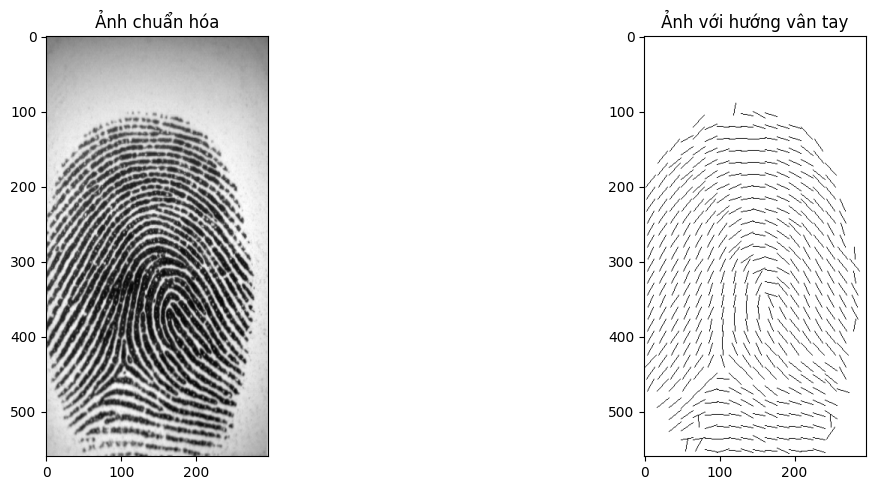

In [11]:
# Tính toán góc phương của vân tay
angles = calculate_angles(normalized_image, W=16)


# Trực quan hóa các góc bằng cách vẽ đường định hướng
orientation_img = visualize_angles(segmented_image, mask, angles, W=16)

# Hiển thị kết quả với matplotlib
plt.figure(figsize=(15,5))


plt.subplot(1,2,1)
plt.imshow(norm_img, cmap='gray')
plt.title("Ảnh chuẩn hóa")

plt.subplot(1,2,2)
plt.imshow(orientation_img, cmap='gray')
plt.title("Ảnh với hướng vân tay")

plt.tight_layout()
plt.show()


Khi phân tích hướng của ảnh (orientation field), có thể có một số **noisy** lớn khiến cho một vài khối có **góc sai lệch rất lớn** so với lân cận (Tuy nhiên vân tay là một cấu trúc có tính mượt, hướng vân sẽ thay đổi liên tục giữa các vùng). Do đó, ta làm mượt toàn bộ ma trận hướng bằng cách chuyển chúng thành **trường vector liên lục**, sau đó áp dụng **low-pass filter** như bộ lọc Gaussian
- Do hướng ảnh có tính đối xứng 180°, nên ta không thể lấy trung bình góc trực tiếp, ta cần ánh xạ từng góc `θ` sang vector đơn vị `cos(2θ)` và `sin(2θ)` để biểu diễn liên tục.
- Sau đó, dùng bộ lọc Gaussian 2D để làm mượt các vector này
- Cuối cùng, chuyển lại về góc `θ` bằng `arctan`.




**Hàm Gauss hai biến (2D Gaussian function):**

In [12]:
def gauss(x, y):
    ssigma = 1.0
    return (1 / (2 * np.pi * (ssigma ** 2))) * np.exp(-(x * x + y * y) / (2 * (ssigma ** 2)))


Tạo một ma trận lọc 2 chiều từ một hàm số hai biến `f(x, y)` như hàm Gaussian. Mỗi phần tử trong kernel được tính bằng cách đưa tọa độ tương đối `(x, y)` (tính từ tâm) vào hàm `f`.

Ví dụ: khi truyền vào hàm `gauss(x, y)`, kết quả sẽ là một kernel Gaussian có tâm ở giữa, với giá trị giảm dần ra rìa.

**Tham số:**
- `size`: kích thước kernel (ví dụ `5` sẽ tạo ra ma trận 5×5).
- `f`: hàm toán học hai biến `(x, y)`.

**Trả về:** một ma trận `size × size` với giá trị được tính từ hàm `f`.

Ở đây ta dùng bộ lọc Gauss 2D vì:
- Làm mượt dữ liệu bằng cách giảm ảnh hưởng của nhiễu tần số cao (những thay đổi đột ngột).
- Trọng số lớn nhất ở trung tâm, càng xa thì càng nhỏ → Ảnh hưởng cục bộ, không làm mờ toàn cục → Vì thế ít gây méo mó thông tin → Không tạo ra rìa gãy khúc như mean/median

In [13]:
def kernel_from_function(size, f):
    kernel = [[] for i in range(0, size)]
    for i in range(0, size):
        for j in range(0, size):
            kernel[i].append(f(i - size / 2, j - size / 2))
    return kernel

Với nha trận Gradien ở trên. Ta cần làm mượt chúng do hướng vân tay có tính liên tục và thay đổi dần giữa các vùng.

In [14]:
def smooth_angles(angles):
    """
    reference: https://airccj.org/CSCP/vol7/csit76809.pdf pg91
    Practically, it is possible to have a block so noisy that the directional estimate is completely false.
    This then causes a very large angular variation between two adjacent blocks. However, a
    fingerprint has some directional continuity, such a variation between two adjacent blocks is then
    representative of a bad estimate. To eliminate such discontinuities, a low-pass filter is applied to
    the directional board.
    :param angles:
    :return:
    """
    angles = np.array(angles)
    cos_angles = np.cos(angles.copy()*2)
    sin_angles = np.sin(angles.copy()*2)

    kernel = np.array(kernel_from_function(5, gauss))

    cos_angles = cv.filter2D(cos_angles/125,-1, kernel)*125
    sin_angles = cv.filter2D(sin_angles/125,-1, kernel)*125
    smooth_angles = np.arctan2(sin_angles, cos_angles)/2

    return smooth_angles

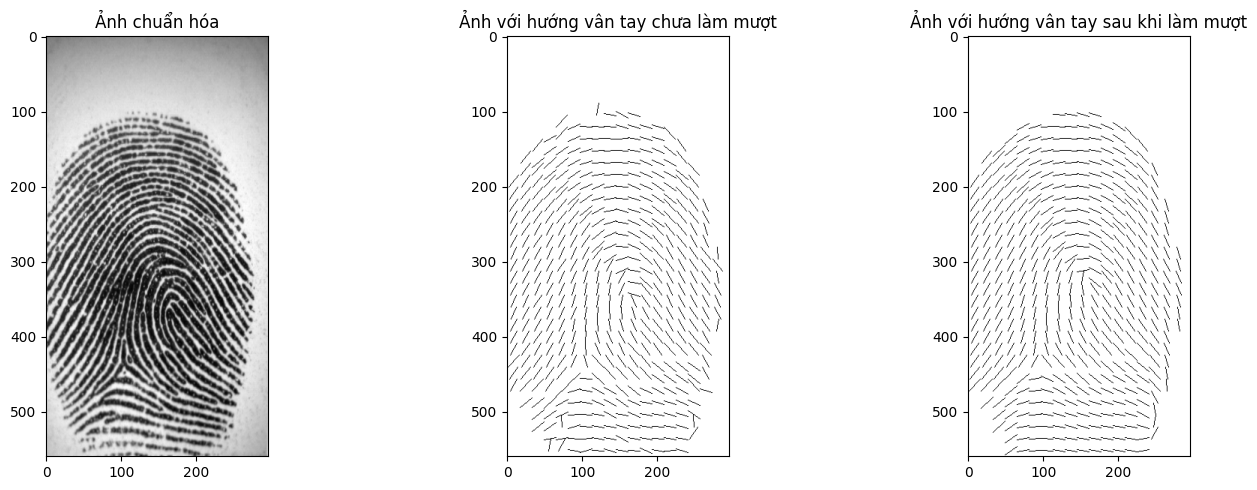

In [15]:
# Làm mượt hướng vân tay
angles = smooth_angles(angles)

# Trực quan hóa
orientation_img_s = visualize_angles(segmented_image, mask, angles, W=16)

# Hiển thị kết quả với matplotlib
plt.figure(figsize=(15,5))


plt.subplot(1,3,1)
plt.imshow(norm_img, cmap='gray')
plt.title("Ảnh chuẩn hóa")

plt.subplot(1,3,2)
plt.imshow(orientation_img, cmap='gray')
plt.title("Ảnh với hướng vân tay chưa làm mượt")

plt.subplot(1,3,3)
plt.imshow(orientation_img_s, cmap='gray')
plt.title("Ảnh với hướng vân tay sau khi làm mượt")

plt.tight_layout()
plt.show()


### **Bước 4: Tính tần số các rãnh vân tay (Ridge Frequency)**

Ta sẽ tính khoảng cách giữa các đường vân để xây dựng bộ lọc Gabor tối ưu hóa cho từng vùng ảnh.


Tính tần số đường vân trong mỗi block của ảnh. Ta sẽ tìm khoảng cách trung bình giữa các rãnh vân tay trong mỗi khối (block), từ đó ước lượng tần số xuất hiện của các rãnh (ridge frequency) trong một vùng cục bộ của ảnh. Tần số này được dùng để lọc và làm nổi bật các rãnh vân. Đây là một đặc trưng quan trọng để xây dựng bộ lọc Gabor nhằm tăng cường ảnh vân tay.

- Chia ảnh đã chuẩn hóa thành các khối w×w (thường là 16×16 pixels). Mỗi block sẽ được xử lý độc lập để ước lượng tần số cục bộ.
- Tại mỗi khối dựa vào orientation map chuyển đổi sao cho các rãnh thành các đường gần thẳng đứng, song song theo chiều dọc
- Thực hiện phép **chiếu xám (gray projection)** theo trục vuông góc với hướng rãnh (Nếu vùng này không có minutiae hay điểm kỳ dị, dãy sẽ có dạng sóng sin.)
- Xác định các đỉnh sóng (peaks):
  - Đếm số đỉnh.
  - Nếu có ít nhất 2 đỉnh, tính khoảng cách trung bình giữa các đỉnh (WaveLength).
  - Tính tần số bằng: $$\frac{1}{\text WaveLength}$$
  - Nếu không phát hiện đủ đỉnh, hoặc WaveLength nằm ngoài ngưỡng cho phép, hàm sẽ trả về ma trận tần số bằng 0.


In [16]:
def frequest(im, orientim, kernel_size, minWaveLength, maxWaveLength):
    """
    Based on https://pdfs.semanticscholar.org/ca0d/a7c552877e30e1c5d87dfcfb8b5972b0acd9.pdf pg.14
    Function to estimate the fingerprint ridge frequency within a small block
    of a fingerprint image.
    An image block the same size as im with all values set to the estimated ridge spatial frequency.  If a
    ridge frequency cannot be found, or cannot be found within the limits set by min and max Wavlength freqim is set to zeros.
    """
    rows, cols = np.shape(im)

    # Tính hướng trung bình của block
    # Thực hiện bằng cách lấy trung bình sin, cos của góc gấp đôi
    # Sau đó chia 2 để tái tạo tại góc
    cosorient = np.cos(2*orientim) # np.mean(np.cos(2*orientim))
    sinorient = np.sin(2*orientim) # np.mean(np.sin(2*orientim))
    block_orient = np.atan2(sinorient,cosorient)/2

    # Xoay block để vân thành dọc đễ dễ dàng đếm số rãnh theo trục dọc
    rotim = scipy.ndimage.rotate(im,
                                 block_orient/np.pi*180 + 90, # Chuyển đổi sang độ, xoay vân thẳng đứng
                                 axes=(1,0),
                                 reshape = False, # giữ nguyên kích thước ảnh.
                                 order = 3, # nội suy cho mượt ảnh
                                 mode = 'nearest') # pixel bị lệch sẽ được gán bằng giá trị gần nhất.)

    # Cắt vùng trung tâm để tránh mép bị lỗi sau khi xoay
    # khi xoay, các góc ngoài dễ bị lỗi, ta chỉ giữ vùng trung tâm hình vuông nhỏ hơn (kích thước: rows / √2).
    cropsze = int(np.fix(rows/np.sqrt(2)))
    offset = int(np.fix((rows-cropsze)/2))
    rotim = rotim[offset:offset+cropsze][:,offset:offset+cropsze]

    # Chiếu ảnh theo trục dọc (cột) để tìm các đỉnh (ridge peak)
    ridge_sum = np.sum(rotim, axis = 0)

    # Tìm đỉnh local trong ridge_sum
    dilation = scipy.ndimage.grey_dilation(ridge_sum, kernel_size, structure=np.ones(kernel_size))
    ridge_noise = np.abs(dilation - ridge_sum); peak_thresh = 2;
    maxpts = (ridge_noise < peak_thresh) & (ridge_sum > np.mean(ridge_sum))
    maxind = np.where(maxpts)
    _, no_of_peaks = np.shape(maxind) # Tính khoảng cách giữa các đỉnh

    # Tính khoảng cách trung bình giữa các đỉnh → Tần số
    if(no_of_peaks<2):
        freq_block = np.zeros(im.shape)
    else:
        # Tính khoảng cách giữa đỉnh đầu và cuối, chia cho số khoảng cách
        # → ra wavelength (khoảng cách trung bình giữa các vân).
        waveLength = (maxind[0][-1] - maxind[0][0])/(no_of_peaks - 1)
        if waveLength>=minWaveLength and waveLength<=maxWaveLength:
            freq_block = 1/np.double(waveLength) * np.ones(im.shape)
        else:
            freq_block = np.zeros(im.shape)
    return(freq_block)

In [17]:
def ridge_freq(im, mask, orient, block_size, kernel_size, minWaveLength, maxWaveLength):
    # Ước lượng tần số vân tay trên toàn ảnh
    rows,cols = im.shape
    freq = np.zeros((rows,cols))
    # Duyệt qua từng block
    for row in range(0, rows - block_size, block_size):
        for col in range(0, cols - block_size, block_size):
            image_block = im[row:row + block_size][:, col:col + block_size]
            angle_block = orient[row // block_size][col // block_size]
            if angle_block:
                freq[row:row + block_size][:, col:col + block_size] = frequest(image_block, angle_block, kernel_size,
                                                                               minWaveLength, maxWaveLength)

    freq = freq*mask # loại bỏ vùng không chứa vân
    # Lấy các tần số khác 0 rồi tính trung vị
    # Ta chọn lấy trung vị thay vì dùng trung bình ...
    # Do trung  vị ít bị ảnh hướng mạnh bởi các giá trị cực trị hoặc outliers
    freq_1d = np.reshape(freq,(1,rows*cols))
    ind = np.where(freq_1d>0)
    ind = np.array(ind)
    ind = ind[1,:]
    non_zero_elems_in_freq = freq_1d[0][ind]
    medianfreq = np.median(non_zero_elems_in_freq) * mask

    return medianfreq

In [18]:
freq = ridge_freq(normalized_image, mask, angles, block_size=16, kernel_size=5, minWaveLength=5, maxWaveLength=15)
print(f"Ma trận Tần số vân tay của ảnh là: {freq}")
freq[200][150]

Ma trận Tần số vân tay của ảnh là: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


np.float64(0.1111111111111111)

### **Bước 5: Tăng Cường Ảnh Vân Tay bằng Gabor Filter**
Ảnh vân tay thường có **nhiễu cao**, tương phản thấp và có thể bị biến dạng. Để xử lý, người ta áp dụng kỹ thuật **tăng cường ảnh (enhancement)** để làm rõ các rãnh vân tay (ridge) và giúp các bước sau như trích đặc trưng (minutiae extraction) hoạt động chính xác hơn.

Một trong những phương pháp tăng cường ảnh phổ biến nhất là **lọc Gabor định hướng** – do Gabor filter có khả năng làm nổi bật các đặc trưng định hướng và tuần hoàn như rãnh vân tay.

 → rất phù hợp với đặc điểm cục bộ của ảnh vân tay.

Từ đó ta có thể làm nổi bậc các rãnh vân theo hướng và tần số cục bộ từ đó giúp nhận dạng tốt hơn.

Phương pháp này được đề xuất trong bài báo:

> **"Fingerprint Image Enhancement: Algorithm and Performance Evaluation" - Hong, Wan, and Jain (1998)**

Gabor filter kết hợp giữa một sóng điều hòa (sinusoidal) và một hàm phân bố Gaussian, được điều chỉnh theo hướng và tần số của rãnh vân tay trong từng block ảnh.



Bộ lọc Gabor là tích của một sóng điều hòa và một hàm phân bố Gaussian. Biểu thức toán học:

$$
G(x, y; f, \theta) = \exp\left(-\left(\frac{x_\theta^2}{2\sigma_x^2} + \frac{y_\theta^2}{2\sigma_y^2}\right)\right) \cdot \cos(2\pi f x_\theta)
$$

Trong đó:
-  $x_\theta = x \cos\theta + y \sin\theta $
-  $y_\theta = -x \sin\theta + y \cos\theta $
- $ f $: tần số của sóng
- $ \theta $: hướng chính của rãnh vân
- $ \sigma_x, \sigma_y $: độ rộng của Gaussian theo hai chiều

Gabor filter có tác dụng làm nổi bật các đường vân có **tần số và hướng cụ thể**, và làm mờ các nhiễu không cùng hướng/tần số.

**Kích thước Gaussian**

$\sigma_x = \frac{1}{f} \cdot k_x,\quad \sigma_y = \frac{1}{f} \cdot k_y$

Tạo các filter theo các hướng (cách nhau gốc 3 độ)

Tại mỗi vị trí hợp lệ $ (r, c) $ trong ảnh, ta lấy một block ảnh $ I_{\text{block}} $ xung quanh điểm đó (kích thước phụ thuộc vào $ \sigma_x, \sigma_y $) và thực hiện tích chập với Gabor filter ứng với hướng và tần số tại điểm đó:

$$
I'(r, c) = \sum_{i=-k}^{k} \sum_{j=-k}^{k} I(r+i, c+j) \cdot G_{f, \theta}(i, j)
$$

Trong đó:
- $ I(r, c) $: giá trị điểm ảnh tại vị trí $ (r, c) $
- $ G_{f, \theta}(i, j) $: Gabor filter với tần số $ f $ và hướng $ \theta $
- $ k $: bán kính của filter kernel (ví dụ $ k = \text{block\_size} $)





In [19]:
def gabor_filter(im, orient, freq, kx=0.5, ky=0.5):
    """
    Gabor filter is a linear filter used for edge detection. Gabor filter can be viewed as a sinusoidal plane of
    particular frequency and orientation, modulated by a Gaussian envelope.
    :param im:
    :param orient:
    :param freq:
    :param kx:
    :param ky:
    :return:
    """
    angleInc = 1
    im = np.double(im)
    rows, cols = im.shape
    return_img = np.zeros((rows,cols))

    # Xử lý ma trận tần số
    freq_1d = freq.flatten() # Chuyển ma trận thành vector dễ xử lý
    frequency_ind = np.array(np.where(freq_1d>0)) # Lấy chỉ số tại các điểm có tần số > 0
    non_zero_elems_in_freq = freq_1d[frequency_ind] # Lấy các giá trị tần số > 0
    non_zero_elems_in_freq = np.double(np.round((non_zero_elems_in_freq*100)))/100 # Làm tròn 0.01
    unfreq = np.unique(non_zero_elems_in_freq) # Lấy danh sách các giá trị tần số duy nhất

    # Tạo một Gabor filter cơ bản (ở hướng 0 độ), dựa trên tập các tần số khác nhau
    sigma_x = 1/unfreq*kx # Độ lệch chuẩn
    sigma_y = 1/unfreq*ky
    # Tạo block chứa filter, kích thước 3 sigma
    block_size = int(np.round(3*np.max([sigma_x,sigma_y])))
    array = np.linspace(-block_size,block_size,(2*block_size + 1))
    x, y = np.meshgrid(array, array)

    # gabor filter cơ bản
    reffilter = np.exp(-(((np.power(x,2))/(2*sigma_x**2) + (np.power(y,2))/(2*sigma_y**2)))) * np.cos(2*np.pi*unfreq[0]*x)
    filt_rows, filt_cols = reffilter.shape
    # Tạo mảng chứa tất cả các gabor filteerr theo từng góc xoay
    gabor_filter = np.array(np.zeros((180//angleInc, filt_rows, filt_cols)))

    # Generate rotated versions of the filter.
    for degree in range(0, 180//angleInc):
        # Xoay bộ lọc
        rot_filt = scipy.ndimage.rotate(reffilter,-(degree*angleInc + 90),reshape = False)
        # Lưu bộ lọc vào mảng
        gabor_filter[degree] = rot_filt

    # chuyển ma trận hướng (orientation matrix) từ đơn vị radian sang chỉ số góc dùng để chọn đúng bộ lọc Gabor
    maxorientindex = np.round(180/angleInc) # số lượng chỉ số hướng
    orientindex = np.round(orient/np.pi*180/angleInc) # Chuyển radian về chỉ số góc
    for i in range(0, rows//16): # Đảm bảo chỉ số trong khoảng hợp lệ
        for j in range(0,cols//16):
            if(orientindex[i][j] < 1):
                orientindex[i][j] = orientindex[i][j] + maxorientindex
            if(orientindex[i][j] > maxorientindex):
                orientindex[i][j] = orientindex[i][j] - maxorientindex

    # Xác định những vị trí hợp lệ trong ảnh để áp dụng bộ lọc Gabor
    block_size = int(block_size)
    valid_row, valid_col = np.where(freq>0)
    finalind = \
        np.where((valid_row>block_size) & (valid_row<rows - block_size) & (valid_col>block_size) & (valid_col<cols - block_size))

    # Áp dụng Gabor filter lên ảnh tại các vị trí finalind để tăng cường ảnh dấu vân tay
    for k in range(0, np.shape(finalind)[1]):
        r = valid_row[finalind[0][k]]; c = valid_col[finalind[0][k]]
        img_block = im[r-block_size:r+block_size + 1][:,c-block_size:c+block_size + 1]
        return_img[r][c] = np.sum(img_block * gabor_filter[int(orientindex[r//16][c//16]) - 1])

    gabor_img = 255 - np.array((return_img < 0)*255).astype(np.uint8)

    return gabor_img



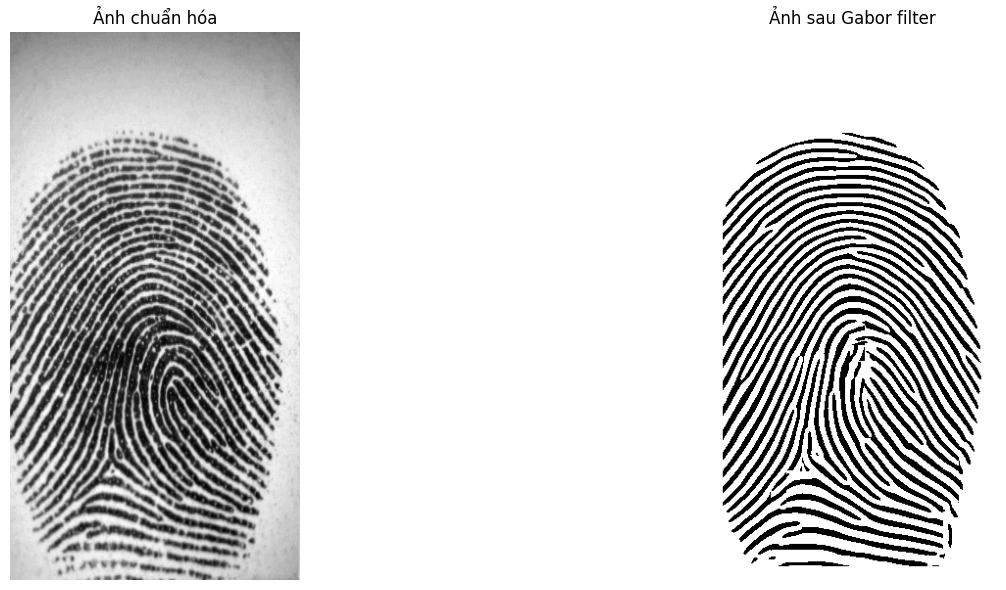

In [20]:
# Áp dụng Gabor filter
gabor_image = gabor_filter(normalized_image, angles, freq)
# Hiển thị kết quả
plt.figure(figsize=(18,6))

# Ảnh chuẩn hóa
plt.subplot(1, 2, 1)
plt.imshow(normalized_image, cmap='gray')
plt.title("Ảnh chuẩn hóa")
plt.axis('off')

# Ảnh sau khi tăng cường bằng Gabor filter
plt.subplot(1, 2, 2)
plt.imshow(gabor_image, cmap='gray')
plt.title("Ảnh sau Gabor filter")
plt.axis('off')

plt.tight_layout()
plt.show()

### **Bước 6: Áp dụng Skeletonization vào ảnh vân tay**
Để nhận dạng được tốt dấu vân tay, việc xác định chính xác các đặc điểm cốt lõi của vân tay (minutiae), chẳng hạn như **nơi kết thúc của rãnh vân tay (ridge ending)** hay **nơi phân nhánh (bifurcation)** là cực kỳ quan trọng.

Tuy nhiên, ảnh nhị phân thu được từ quá trình tiền xử lý (như lọc Gabor, làm mượt, nhị phân hóa) thường vẫn chứa các đường vân dày và không đều. Điều này gây khó khăn trong việc phát hiện minutiae một cách chính xác.


Áp dụng **Thuật toán Guo-Hall Thinning** để giảm độ dày của các rãnh vân tay xuống còn **1 pixel**.
Nhưng vẫn **giữ nguyên cấu trúc và hình dạng** của vân tay. Thuật toán sẽ loại bỏ các pixel thừa không cần thiết mà không làm mất đi các đặc trưng quan trọng.





In [21]:
from skimage.morphology import thin  # Guo–Hall thinning
from skimage.util import invert

In [22]:
def skeletonize_guo_hall(image_input):
    """
    Áp dụng Guo–Hall Thinning để làm mỏng ảnh nhị phân (dùng skimage.thin).
    :param image_input: ảnh nhị phân (2D array, uint8) với giá trị 0 (đen) và 255 (trắng)
    :return: ảnh đã làm mỏng (1-pixel width skeleton)
    """
    # Bước 1: Chuyển ảnh trắng–đen về ảnh nhị phân 0–1
    # Đảo ngược ảnh nếu cần vì thin() yêu cầu foreground = 1, background = 0
    image = np.zeros_like(image_input, dtype=np.uint8)
    image[image_input == 0] = 1  # foreground: 1

    # Bước 2: Guo–Hall thinning
    skeleton = thin(image)  # thuật toán Guo–Hall (skimage)

    # Bước 3: Đưa kết quả về ảnh uint8 với giá trị 0–255
    output = np.zeros_like(image_input, dtype=np.uint8)
    output[skeleton] = 255

    # Bước 4: Đảo lại nếu cần (tùy yêu cầu thuật toán downstream)
    cv.bitwise_not(output, output)

    return output

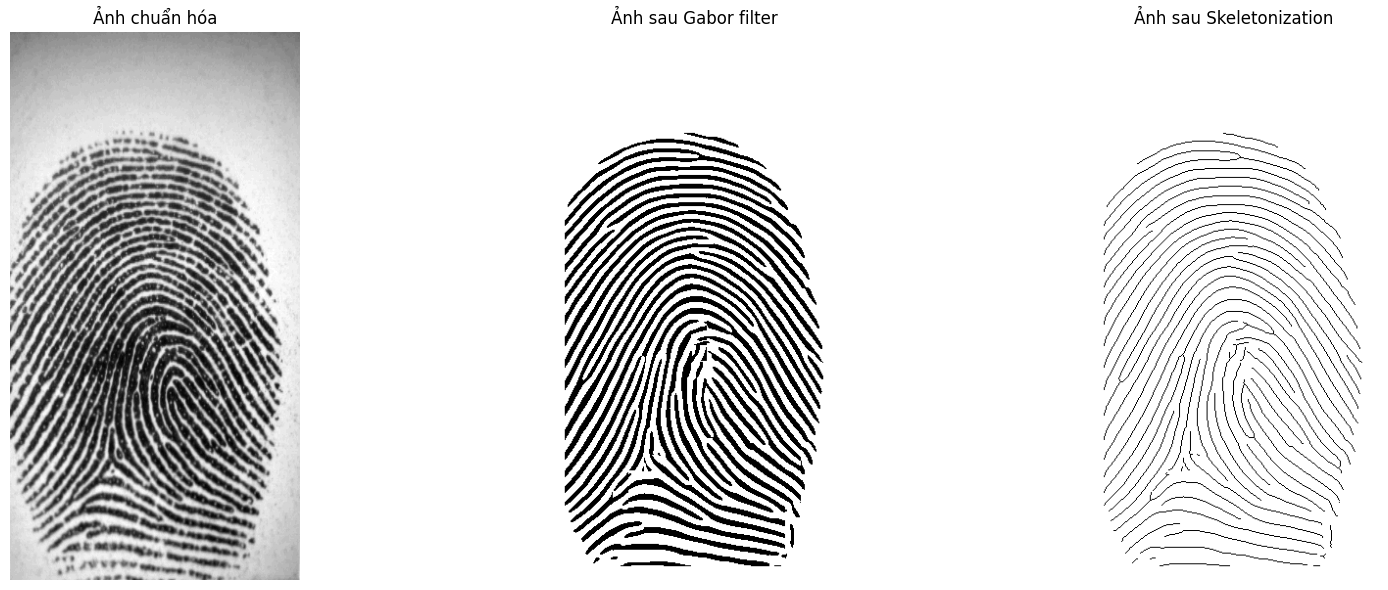

In [23]:
# Áp dụng Skeletonization
skeleton = skeletonize_guo_hall(gabor_image)

# Hiển thị kết quả
plt.figure(figsize=(18,6))

# Ảnh chuẩn hóa
plt.subplot(1, 3, 1)
plt.imshow(normalized_image, cmap='gray')
plt.title("Ảnh chuẩn hóa")
plt.axis('off')

# Ảnh sau khi tăng cường bằng Gabor filter
plt.subplot(1, 3, 2)
plt.imshow(gabor_image, cmap='gray')
plt.title("Ảnh sau Gabor filter")
plt.axis('off')

# Ảnh sau khi tăng cường bằng Gabor filter
plt.subplot(1, 3, 3)
plt.imshow(skeleton, cmap='gray')
plt.title("Ảnh sau Skeletonization")
plt.axis('off')

plt.tight_layout()
plt.show()

### **Bước 7: Xác định các Minutiae**
Minutiae là những đặc điểm cục bộ quan trọng trong ảnh vân tay, bao gồm:
- **Ridge Ending (kết thúc rãnh):** nơi một rãnh kết thúc đột ngột.
- **Ridge Bifurcation (phân nhánh rãnh):** nơi một rãnh chia ra thành hai hoặc nhiều nhánh.

Một trong những phương pháp đơn giản nhưng hiệu quả để phát hiện các đặc trưng này là **Crossing Number Algorithm (CN)**.

- Khi ảnh vân tay đã được **skeleton hóa** (làm mỏng xuống còn 1 pixel độ rộng), rãnh vân được biểu diễn bằng các pixel màu đen (giá trị `1`), còn nền là màu trắng (giá trị `0`).
- Nếu xét một điểm nằm trên rãnh (pixel = `1`), thì **sự thay đổi giữa 0 và 1** ở các pixel lân cận sẽ tiết lộ cấu trúc xung quanh điểm đó từ đó ta có thể biết điểm đó là điểm kết thúc (ending) hay điểm phân nhánh(bifurcation).

Với mỗi điểm ảnh trung tâm `(i, j)` có giá trị `1` (nằm trên rãnh):
- Xét **8 pixel lân cận** bao quanh nó theo chiều kim đồng hồ:
$$
\left[
\begin{array}{ccc}
P1 & P2 & P3 \\
P8 & 1 & P4 \\
P7 & P6 & P5 \\
\end{array}
\right]
$$
- Tạo một danh sách `values` chứa giá trị của các điểm lân cận.
- Đếm số lần xảy ra chuyển đổi từ `0 → 1` hoặc `1 → 0` trong chuỗi.
- Chia đôi kết quả để lấy số lần "crossing".
  - **1 lần chuyển đổi**: điểm kết thúc (ending).
  - **3 lần chuyển đổi**: điểm phân nhánh (bifurcation).

Ví dụ ma trận 3x3 pixel:
- Với ma trận:
$$
\left[
\begin{array}{ccc}
0 & 1 & 0 \\
0 & 1 & 0 \\
0 & 1 & 0 \\
\end{array}
\right]
$$

  - Pixel trung tâm X = 1  
  - Dãy pixel biên: [P1, P2, P3, P4, P5, P6, P7, P8] = `[0, 1, 0, 0, 0, 1, 0, 0]`

  → số chuyển đổi = 4  
  → CN = 4 / 2 = **2** → Không phải minutiae.
- Với ma trận:
$$
\left[
\begin{array}{ccc}
0 & 1 & 0 \\
0 & 1 & 0 \\
0 & 0 & 0 \\
\end{array}
\right]
$$
  - Pixel trung tâm X = 1  
  - Dãy pixel biên: [P1, P2, P3, P4, P5, P6, P7, P8] = `[0, 1, 0, 0, 0, 0, 0, 0]`

  → số chuyển đổi = 2  
  → CN = 2 / 2 = **1** → **điểm kết thúc (ending)**

- Với ma trận:
$$
\left[
\begin{array}{ccc}
0 & 1 & 0 \\
0 & 1 & 0 \\
1 & 0 & 1 \\
\end{array}
\right]
$$
  - Pixel trung tâm X = 1  
  - Dãy pixel biên: [P1, P2, P3, P4, P5, P6, P7, P8] = `[0, 1, 0, 0, 1, 0, 1, 0]`

  → số chuyển đổi = 6  
  → CN = 6 / 2 = **3** → **điểm phân nhánh (bifurcation)**

In [24]:
def minutiae_at(pixels, i, j):
    """
     kiểm tra một pixel tại vị trí (i, j) trong ảnh nhị phân, và xác định xem
     có phải là một điểm kết thúc (ridge ending) hay một điểm nhánh (ridge bifurcation) hay không.
    """
    # Kiểm tra xem pixel có phải rãnh không
    if pixels[i][j] == 1:

        cells = [(-1, -1), (-1, 0), (-1, 1),        # p1 p2 p3
                   (0, 1),  (1, 1),  (1, 0),        # p8    p4
                  (1, -1), (0, -1), (-1, -1)]       # p7 p6 p5
        values = [pixels[i + l][j + k] for k, l in cells]

        # Đếm số lần crossing
        crossings = 0
        for k in range(0, len(values)-1):
            # Số lần chuyển từ 0 sang 1 và từ 1 sang 0
            crossings += abs(values[k] - values[k + 1])
        crossings //= 2

        if crossings == 1: # là ridge ending
            return "ending"
        if crossings == 3: # là ridge bifurcation
            return "bifurcation"

    return "none"

Đánh dấu các điểm minutiaes lên ảnh

In [25]:
def mark_minutiae_on_image(image, kernel_size=3):
    """
    Phát hiện điểm minutiae (kết thúc và phân nhánh) bằng thuật toán Crossing Number.

    Parameters:
        image (ndarray): Ảnh xám đã skeleton hóa (giá trị 0 hoặc 255).
        kernel_size (int): Kích thước kernel để kiểm tra lân cận (mặc định là 3).

    Returns:
        result (ndarray): Ảnh RGB hiển thị các điểm minutiae bằng màu sắc.
    """
    # Nhị phân hóa ảnh: 0 (nền) → 0, pixel < 10 (rãnh) → 1
    binary_image = np.zeros_like(image)
    binary_image[image < 10] = 1
    binary_image = binary_image.astype(np.int8)

    height, width = image.shape

    # Chuyển ảnh xám sang RGB để dễ vẽ màu lên
    result = cv.cvtColor(image, cv.COLOR_GRAY2RGB)

    # Định nghĩa màu cho từng loại minutiae
    colors = {
        "ending": (150, 0, 0),        # Màu đỏ: điểm kết thúc
        "bifurcation": (0, 150, 0)    # Màu xanh lá: điểm phân nhánh
    }

    # Duyệt từng pixel (tránh viền)
    offset = kernel_size // 2
    for y in range(offset, height - offset):
        for x in range(offset, width - offset):
            # Xác định loại minutiae tại vị trí (x, y)
            minutiae_type = minutiae_at(binary_image, y, x)

            # Nếu là ending hoặc bifurcation thì vẽ vòng tròn
            if minutiae_type in colors:
                cv.circle(result, (x, y), radius=2, color=colors[minutiae_type], thickness=2)

    return result

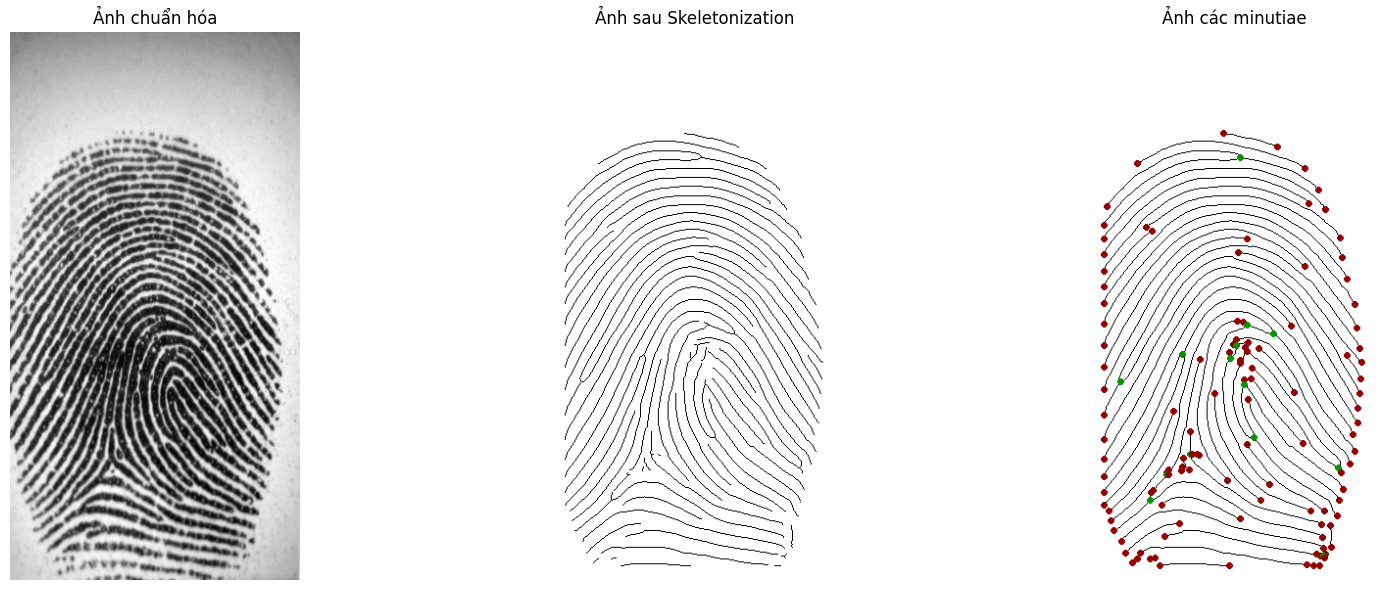

In [26]:
# Đánh dầu các điểm minutiae
minutiae_image = mark_minutiae_on_image(skeleton)

# Hiển thị kết quả
plt.figure(figsize=(18,6))

# Ảnh chuẩn hóa
plt.subplot(1, 3, 1)
plt.imshow(normalized_image, cmap='gray')
plt.title("Ảnh chuẩn hóa")
plt.axis('off')

# Ảnh sau khi tăng cường bằng Gabor filter
plt.subplot(1, 3, 2)
plt.imshow(skeleton, cmap='gray')
plt.title("Ảnh sau Skeletonization")
plt.axis('off')

# Ảnh đánh dầu các điểm minutiae
plt.subplot(1, 3, 3)
plt.imshow(minutiae_image, cmap='gray')
plt.title("Ảnh các minutiae")
plt.axis('off')

plt.tight_layout()
plt.show()

### **Bước 8: Xác định các Singularities bằng Poincaré Index**

**Singularities** là những điểm đặc biệt trong cấu trúc vân tay, nơi các đường vân (ridges) hội tụ, phân kỳ hoặc uốn cong mạnh mẽ theo một kiểu không đều. Những điểm này đóng vai trò quan trọng trong việc định danh và phân loại dấu vân tay.

Có 3 loại singularities chính:
- **Loop** (vòng xoáy mở)
- **Delta** (điểm phân kỳ)
- **Whorl** (vòng xoáy kín)

Để xác định các singularities này, ta thực hiện các bước sau:
1. Chia ảnh vân tay thành các block nhỏ.
2. Lấy 8 block xung quanh một block trung tâm.
3. Trích xuất **góc định hướng** (orientation angle) tại mỗi block xung quanh từ ma trận góc (angles). Các góc này thể hiện hướng của vân tay tại từng block.
4. Tính hiệu góc giữa các block liên tiếp (p1-p2, p2-p3, ..., p8-p1), sau đó chuẩn hóa các hiệu góc này về khoảng [−90°, +90°] để tránh sự nhảy sai chiều (vì góc 180° ≡ -180°).
5. Tính tổng của các hiệu góc sau khi chuẩn hóa:
    - Nếu tổng gần **+180°**, đó là **Loop**.
    - Nếu tổng gần **–180°**, đó là **Delta**.
    - Nếu tổng gần **+360°**, đó là **Whorl**.
    - Các trường hợp khác sẽ không có singularity tại vị trí đó.


In [27]:
def poincare_index_at(i, j, angles, tolerance):
    """
    xác định loại singularity (Loop, Delta, Whorl) tại một điểm (i, j)
    trong ma trận góc định hướng của dấu vân tay, dựa trên Poincaré Index.
    """

    # Cấu trúc giúp lấy 8 blocks xung quanh (i,j)
    cells = [(-1, -1), (-1, 0), (-1, 1),         # p1 p2 p3
            (0, 1),  (1, 1),  (1, 0),            # p8    p4
            (1, -1), (0, -1), (-1, -1)]          # p7 p6 p5

    # Trích xuất các góc định hướng xung quanh điểm (i, j)
    angles_around_index = [math.degrees(angles[i - k][j - l]) for k, l in cells]
    # Tính toán chênh lệch giữa các góc định hướng của các block liên tiếp
    index = 0
    for k in range(0, 8):

        # Tính chênh lệch
        difference = angles_around_index[k] - angles_around_index[k + 1]
        # Chuẩn hóa sao cho chênh lệch trong khoảng [-90,+90]
        if difference > 90:
            difference -= 180
        elif difference < -90:
            difference += 180

        index += difference

    if 180 - tolerance <= index <= 180 + tolerance:
        return "loop"
    if -180 - tolerance <= index <= -180 + tolerance:
        return "delta"
    if 360 - tolerance <= index <= 360 + tolerance:
        return "whorl"
    return "none"

In [28]:
def calculate_singularities(im, angles, tolerance, W, mask):
    # Chuyển ảnh về định dạng màu để vẽ trực quan
    result = cv.cvtColor(im, cv.COLOR_GRAY2RGB)

    # DELTA: RED, LOOP:ORAGNE, whorl:INK
    colors = {
        "loop" : (0, 0, 255),       # Đỏ
        "delta" : (0, 128, 255),    # Cam
        "whorl": (255, 153, 255)    # Hồng
        }
    # Duyệt qua các block từ (3,3) đến gần sát biên để đảm bảo có đủ 8 block xung quanh
    # (vì tính Poincaré Index cần 8 điểm lân cận).
    for i in range(3, len(angles) - 2):             # theo chiều dọc Y
        for j in range(3, len(angles[i]) - 2):      # theo chiều ngang x
            # dùng mask để kiểm tra block có nằm trong vùng có dấu vân tay không
            mask_slice = mask[(i-2)*W:(i+3)*W, (j-2)*W:(j+3)*W]
            mask_flag = np.sum(mask_slice) # Đây là vùng nằm hoàn toán trong mask
            if mask_flag == (W*5)**2:
                singularity = poincare_index_at(i, j, angles, tolerance)
                if singularity != "none":
                    cv.rectangle(result, ((j+0)*W, (i+0)*W), ((j+1)*W, (i+1)*W), colors[singularity], 3)

    return result

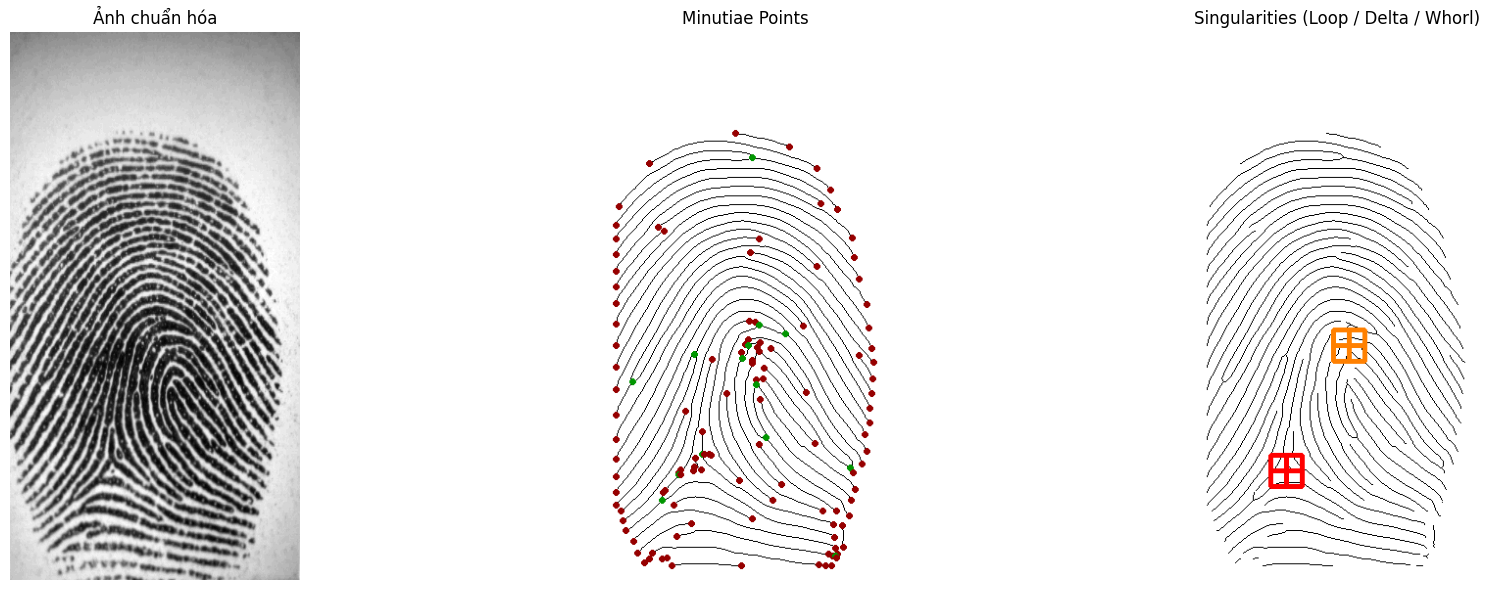

In [29]:
# Xác định singularities (Loop, Delta, Whorl)
singularity_image = calculate_singularities(skeleton, angles, 1, 16, mask)
singularity_image_rgb = cv.cvtColor(singularity_image, cv.COLOR_BGR2RGB)

# Bước 5: Hiển thị kết quả
plt.figure(figsize=(20, 6))

# Ảnh chuẩn hóa
plt.subplot(1, 3, 1)
plt.imshow(normalized_image, cmap='gray')
plt.title("Ảnh chuẩn hóa")
plt.axis('off')

# Ảnh minutiae
plt.subplot(1, 3, 2)
plt.imshow(minutiae_image, cmap='gray')
plt.title("Minutiae Points")
plt.axis('off')

# Ảnh Singularities
plt.subplot(1, 3, 3)
plt.imshow(singularity_image_rgb)
plt.title("Singularities (Loop / Delta / Whorl)")
plt.axis('off')

plt.tight_layout()
plt.show()